<div style="background: linear-gradient(135deg, #4C1D95 0%, #F5F3FF 100%); padding: 24px; border-radius: 12px; color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.1);">
    <h1 style="margin: 0 0 8px 0; color: #ffffff; font-size: 26px; font-weight: 800; border-bottom: none; padding: 0;">Classroom Analysis</h1>
    <div style="background: rgba(255, 255, 255, 0.2); padding: 8px 14px; border-radius: 6px; font-size: 13px; display: inline-block;">
        <strong>Author:</strong> Kathryn Penrod &nbsp;•&nbsp; 
        <strong>Goal:</strong> Find trends in data set 2
    </div>
</div>

In [1]:
import numpy as np 
import pandas as pd 
import scipy as sp 
from scipy import stats 
import matplotlib 
import sqlite3 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import seaborn as sns 
import sklearn 
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
import warnings 
import re

all_dfs = pd.read_pickle('all_clean_dfs3.pkl')

df = all_dfs['df']
clean_df = all_dfs['clean_df']
clean_df2 = all_dfs['clean_df2']
clean_df3 = all_dfs['clean_df3']

In [2]:
print(clean_df2.columns.tolist())

['Pre-Test', 'RN.2.1 - Exit Ticket 1', 'RN.2.1 - Exit Ticket 2', 'RN.2.1 - Mastery', 'RN.2.2 - CFU', 'RN.2.2 - Exit', 'RN.2.2 - Mastery', 'RN.3.3 - CFU - AGGMO', 'RN.3.3 - Mastery', 'W.3.3 - Exit - HW', 'W.3.3 - Mastery', 'W.6.2 - Exit Commas', 'W.6.2 - Exit Clauses', 'W.6.2 - Exit conj', 'W.6.2 - Mastery Combo', 'RL.2.1 - practice 1', 'RL.2.1 - practice 2', 'RL.2.3 - Exit Ticket 2. 18', 'RL.2.3 - Exit Ticket 2.20', 'RL.2.3 - Mastery 2.28', 'Post Test 1']


In [3]:
rename_dict = {
    'Pre-Test': 'Pre_Test',
    'RN.2.1 - Exit Ticket 1': 'RN21_Exit1',
    'RN.2.1 - Exit Ticket 2': 'RN21_Exit2',
    'RN.2.1 - Mastery': 'RN21_Mastery',
    'RN.2.2 - CFU': 'RN22_CFU',
    'RN.2.2 - Exit': 'RN22_Exit',
    'RN.2.2 - Mastery': 'RN22_Mastery',
    'RN.3.3 - CFU - AGGMO': 'RN33_CFU',
    'RN.3.3 - Mastery': 'RN33_Mastery',
    'W.3.3 - Exit - HW': 'W33_Exit_HW',
    'W.3.3 - Mastery': 'W33_Mastery',
    'W.6.2 - Exit Commas': 'W62_Exit_Commas',
    'W.6.2 - Exit Clauses': 'W62_Exit_Clauses',
    'W.6.2 - Exit conj': 'W62_Exit_Conj',
    'W.6.2 - Mastery Combo': 'W62_Mastery_Combo',
    'RL.2.1 - practice 1': 'RL21_Practice1',
    'RL.2.1 - practice 2': 'RL21_Practice2',
    'RL.2.3 - Exit Ticket 2. 18': 'RL23_Exit_18',
    'RL.2.3 - Exit Ticket 2.20': 'RL23_Exit_20',
    'RL.2.3 - Mastery 2.28': 'RL23_Mastery_28',
    'Post Test 1': 'Post_Test_1'
}

clean_df2 = clean_df2.rename(columns=rename_dict)

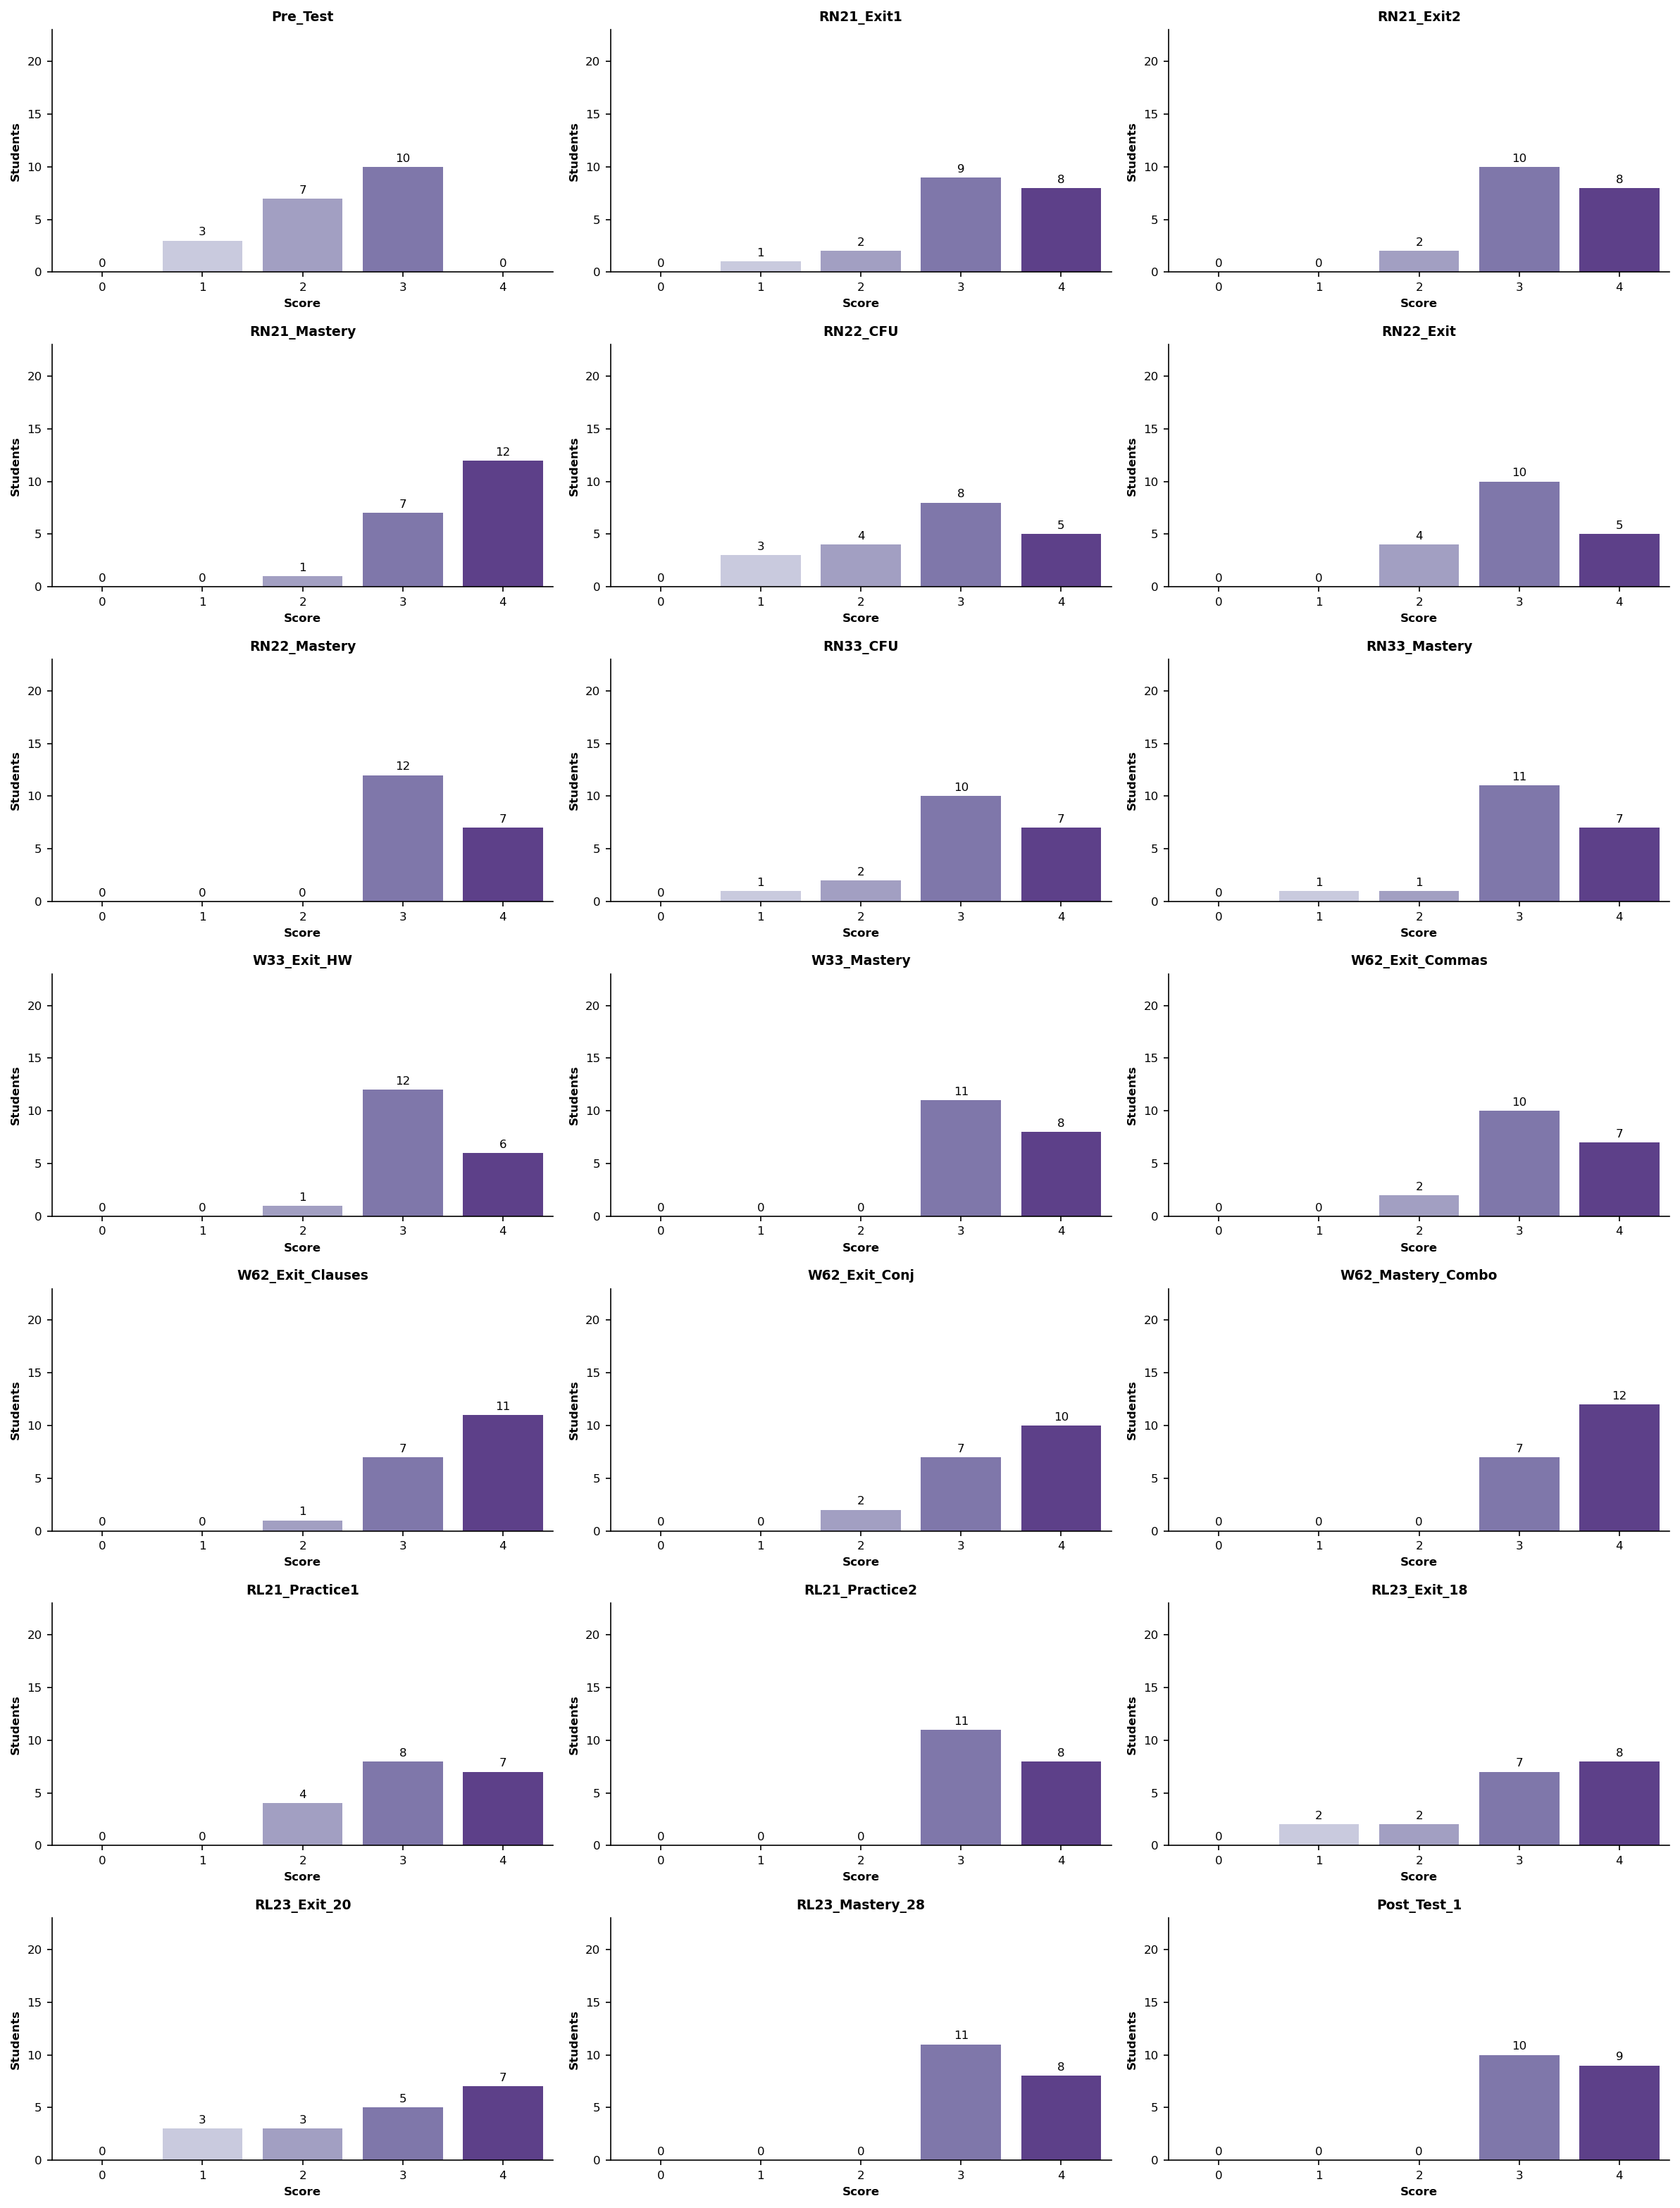

In [4]:
#loop through tests to show scores for each

# Automatically get all numeric columns, minus any you want to ignore
ignore_cols = ['']
assessment_columns = [
    col for col in clean_df2.select_dtypes(include='number').columns 
    if col not in ignore_cols
]

#bins&labels
bins = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
labels = ['0', '1', '2', '3', '4']

valid_cols = [col for col in assessment_columns if col in clean_df2.columns]
n_cols = len(valid_cols)

if n_cols > 0:
  ncols_grid = 3
  nrows_grid = (n_cols + ncols_grid - 1) // ncols_grid

#sizing
  fig, axes = plt.subplots(
      nrows_grid, ncols_grid, figsize=(16, 3 * nrows_grid), dpi=150
  )
  axes = axes.flatten()

    #scores into freq count
  for i, col in enumerate(valid_cols):
    ax = axes[i]
    temp_df = clean_df2.copy()
    temp_df['Score_Bin'] = pd.cut(temp_df[col], bins=bins, labels=labels)
    score_counts = (
        temp_df.groupby('Score_Bin', observed=False)
        .size()
        .reset_index(name='Student_Count')
    )

      #fomatting figure
    sns.barplot(
        data=score_counts,
        x='Score_Bin',
        y='Student_Count',
        hue='Score_Bin',
        palette='Purples',
        legend=False,
        ax=ax,
    )

    for container in ax.containers:
      ax.bar_label(container, fmt='%d', padding=2, fontsize=8)
#formatting & labels
    sns.despine(ax=ax, top=True, right=True)
    ax.set_title(col, fontsize=9, fontweight='bold', pad=6)
    ax.set_xlabel('Score', fontsize=8, fontweight='bold')
    ax.set_ylabel('Students', fontsize=8, fontweight='bold')
    ax.tick_params(axis='both', labelsize=8)
    ax.set_ylim(
        0, clean_df2.shape[0] * 1.15
    )  

  plt.tight_layout()
  plt.show()

In [5]:
#quick look at different aspects

# Make sure your score columns are numeric (coercing any remaining text/abs to NaN)
score_cols = [col for col in clean_df2.columns if col != 'Student']
for col in score_cols:
    clean_df2[col] = pd.to_numeric(clean_df2[col], errors='coerce')

print("="*60)
print("1. STANDARD-LEVEL MASTERY (Class Averages)")
print("="*60)
# Calculate class average for every assessment/standard
class_averages = clean_df2[score_cols].mean().round(2)
print(class_averages.sort_values(ascending=False))
print("\n")


print("="*60)
print("2. PRE-VS-POST GROWTH & FORMATIVE PROGRESSION")
print("="*60)
# Check if Pre-Test and Post-Test exist and calculate student growth delta
if 'Pre_Test' in clean_df2.columns and 'Post_Test_1' in clean_df2.columns:
    clean_df2['Overall_Growth'] = clean_df2['Post_Test_1'] - clean_df2['Pre_Test']
    print(f"Average Class Growth (Post-Test minus Pre-Test): {clean_df2['Overall_Growth'].mean():.2f}")
    
# Compare averages across assessment types (CFU vs Exit vs Mastery)
cfu_list = [c for c in score_cols if 'CFU' in c]
exit_list = [c for c in score_cols if 'Exit' in c or 'practice' in c]
mastery_list = [c for c in score_cols if 'Mastery' in c]

print(f"Average CFU Score across class: {clean_df2[cfu_list].mean().mean():.2f}")
print(f"Average Exit Ticket Score across class: {clean_df2[exit_list].mean().mean():.2f}")
print(f"Average Mastery Score across class: {clean_df2[mastery_list].mean().mean():.2f}")
print("\n")


print("="*60)
print("3. STUDENT TIERING & INTERVENTION ROSTER")
print("="*60)
# Calculate each student's average mastery score
mastery_cols_exist = [c for c in mastery_list if c in clean_df2.columns]
clean_df2['Avg_Mastery'] = clean_df2[mastery_cols_exist].mean(axis=1)

# Identify students needing intervention (Average mastery below 2.5 i.e., below/developing)
intervention_group = clean_df2[clean_df2['Avg_Mastery'] < 2.5]
print(f"Students needing small-group intervention ({len(intervention_group)} students):")
if 'Student' in clean_df2.columns:
    print(intervention_group[['Avg_Mastery']])
else:
    print(intervention_group[['Avg_Mastery']])
print("\n")

1. STANDARD-LEVEL MASTERY (Class Averages)
W62_Mastery_Combo    3.63
RN21_Mastery         3.58
W62_Exit_Clauses     3.53
Post_Test_1          3.47
W33_Mastery          3.42
W62_Exit_Conj        3.42
RL21_Practice2       3.42
RL23_Mastery_28      3.42
RN21_Exit2           3.38
RN22_Mastery         3.37
W33_Exit_HW          3.26
W62_Exit_Commas      3.26
RN21_Exit1           3.22
RN33_Mastery         3.20
RL21_Practice1       3.16
RN33_CFU             3.15
RL23_Exit_18         3.11
RN22_Exit            3.05
RL23_Exit_20         2.89
RN22_CFU             2.75
Pre_Test             2.35
dtype: float64


2. PRE-VS-POST GROWTH & FORMATIVE PROGRESSION
Average Class Growth (Post-Test minus Pre-Test): 1.05
Average CFU Score across class: 2.95
Average Exit Ticket Score across class: 3.24
Average Mastery Score across class: 3.44


3. STUDENT TIERING & INTERVENTION ROSTER
Students needing small-group intervention (1 students):
   Avg_Mastery
3          1.5




/tmp/ipykernel_173/278100349.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


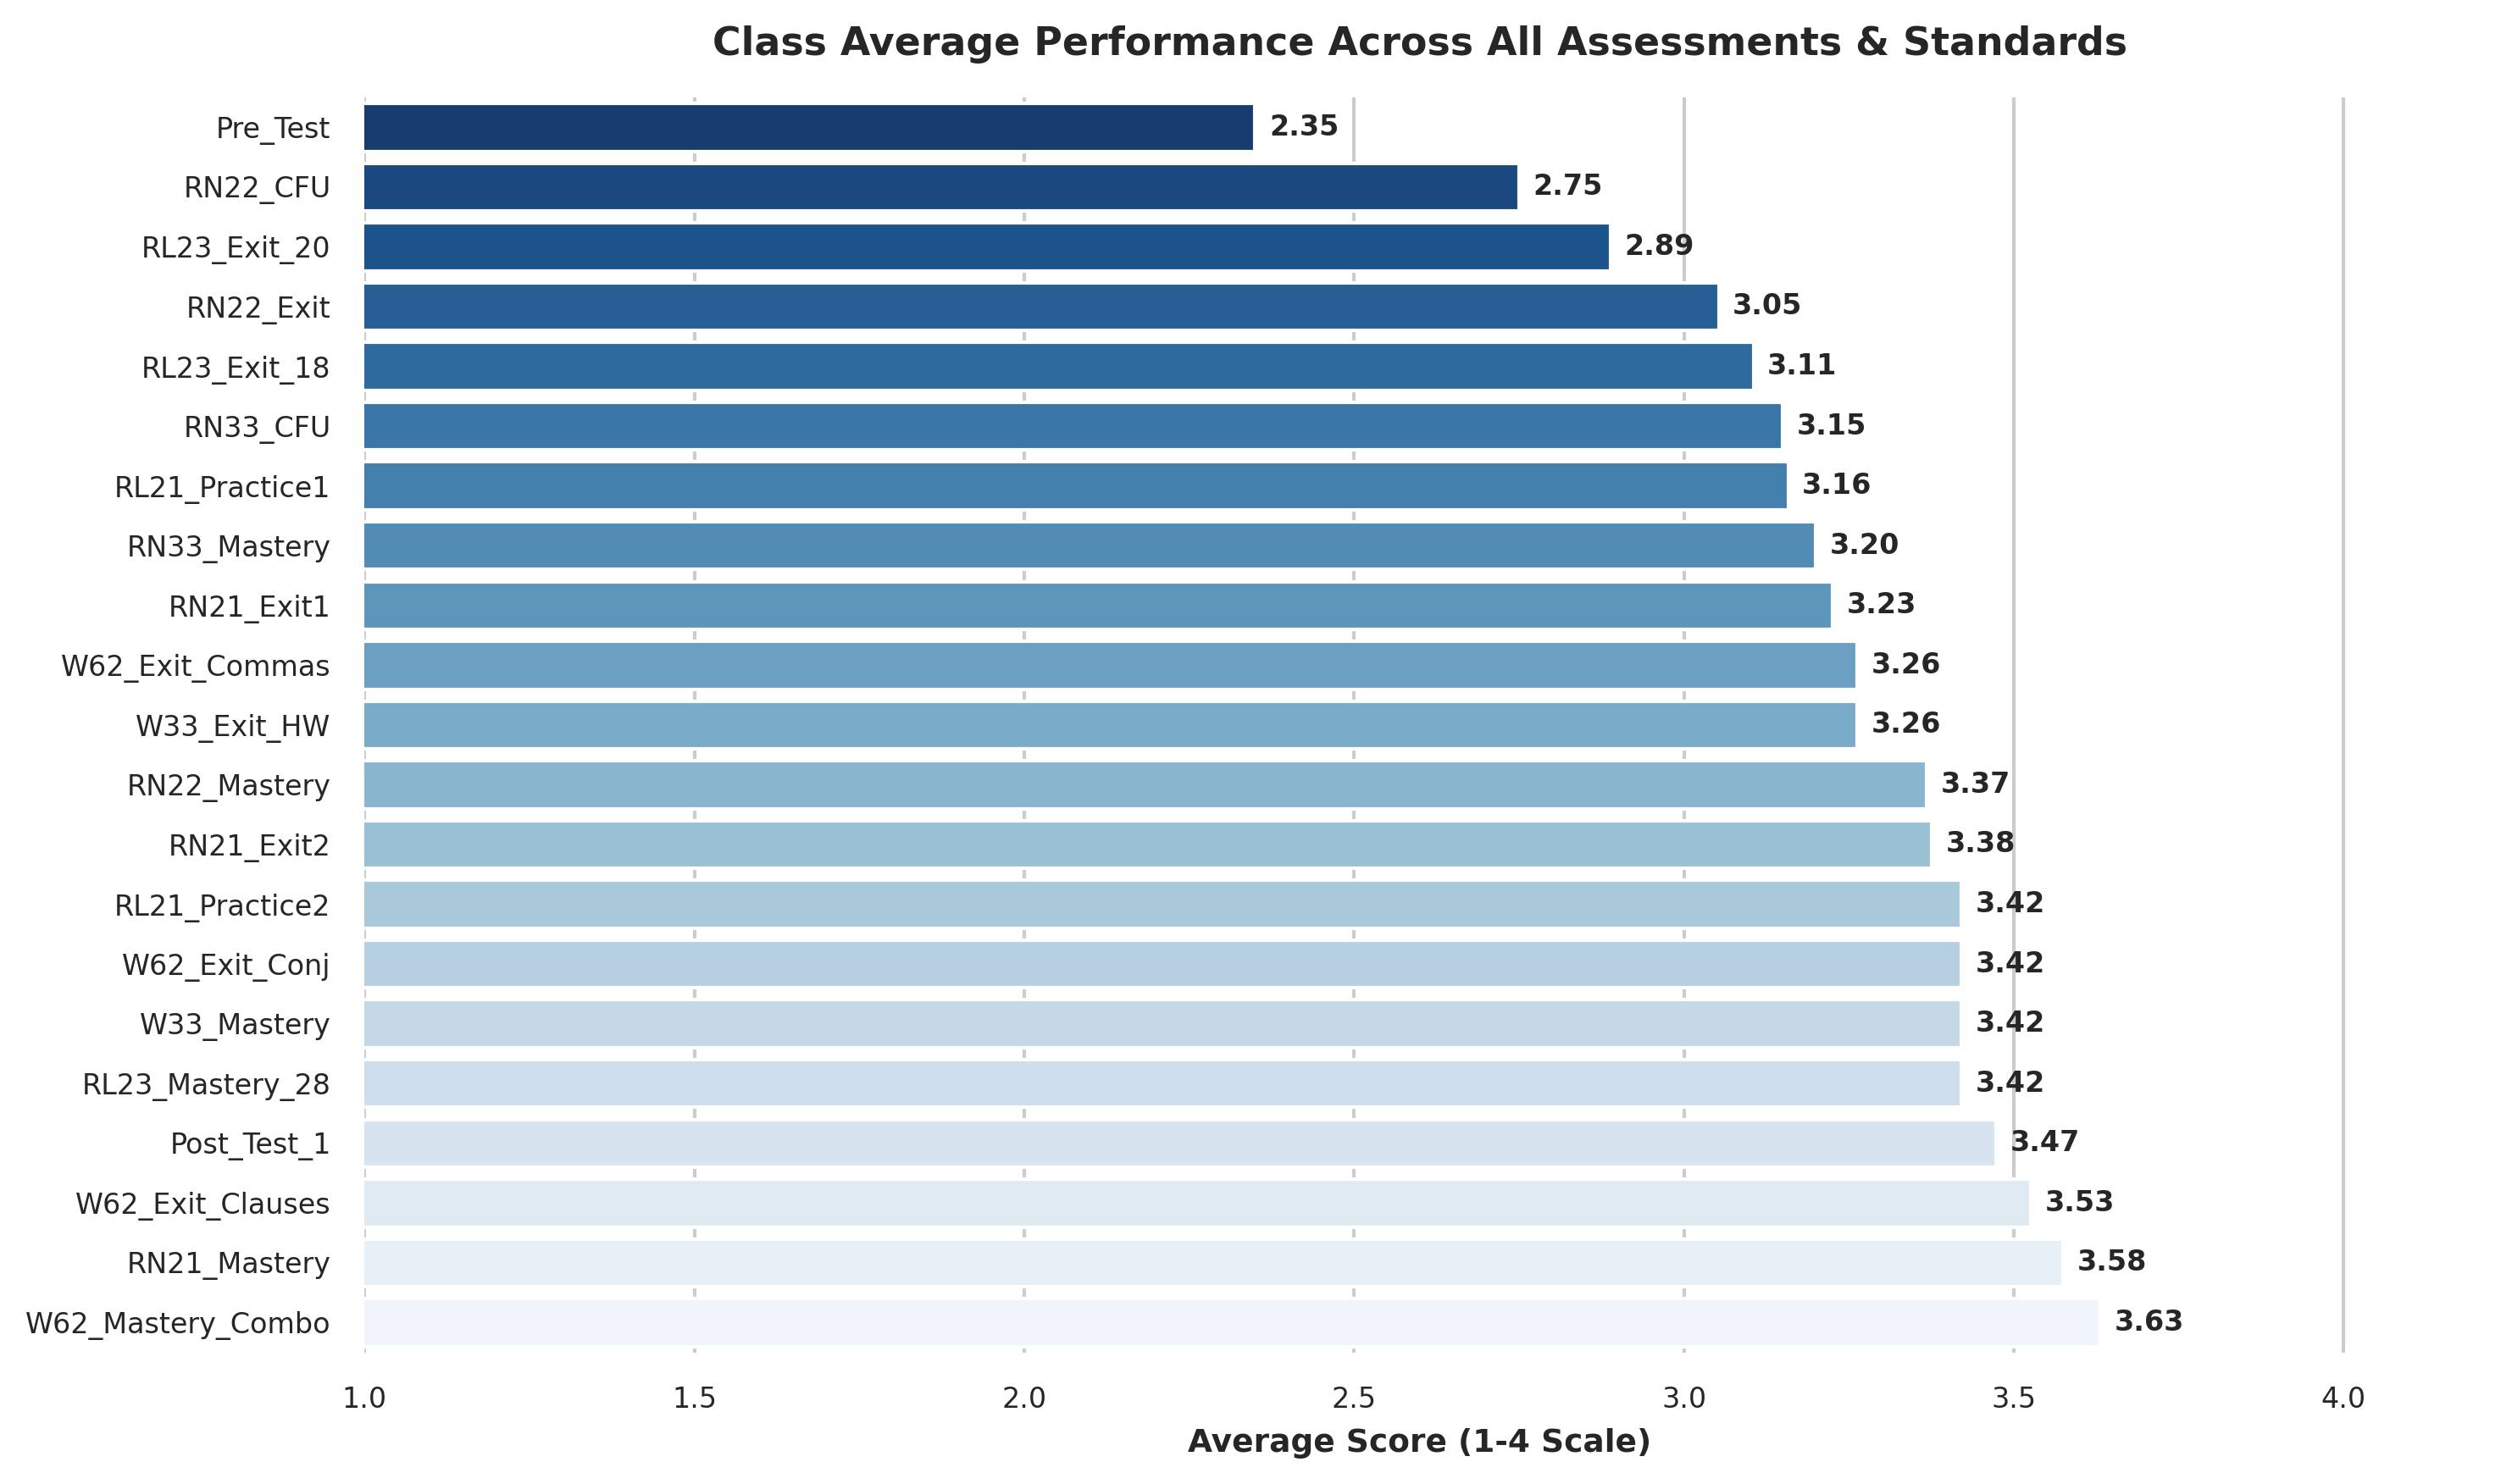

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate class averages and sort them
score_cols = [col for col in clean_df2.columns if col not in ['STUDENT', 'Student', 'Total_Absences', 'Overall_Growth', 'Avg_Mastery']]
std_means = clean_df2[score_cols].mean().sort_values(ascending=True)

plt.figure(figsize=(10, 6), dpi=300)
sns.set_theme(style="whitegrid")

# Create horizontal bar chart
ax = sns.barplot(
    x=std_means.values, 
    y=std_means.index, 
    palette="Blues_r"
)

# Add value labels to the end of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=4, fontsize=8, fontweight='bold')

plt.title("Class Average Performance Across All Assessments & Standards", fontsize=11, fontweight='bold', pad=12)
plt.xlabel("Average Score (1-4 Scale)", fontsize=9, fontweight='bold')
plt.ylabel("", fontsize=9)
plt.xlim(1, 4.2)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_173/927768645.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


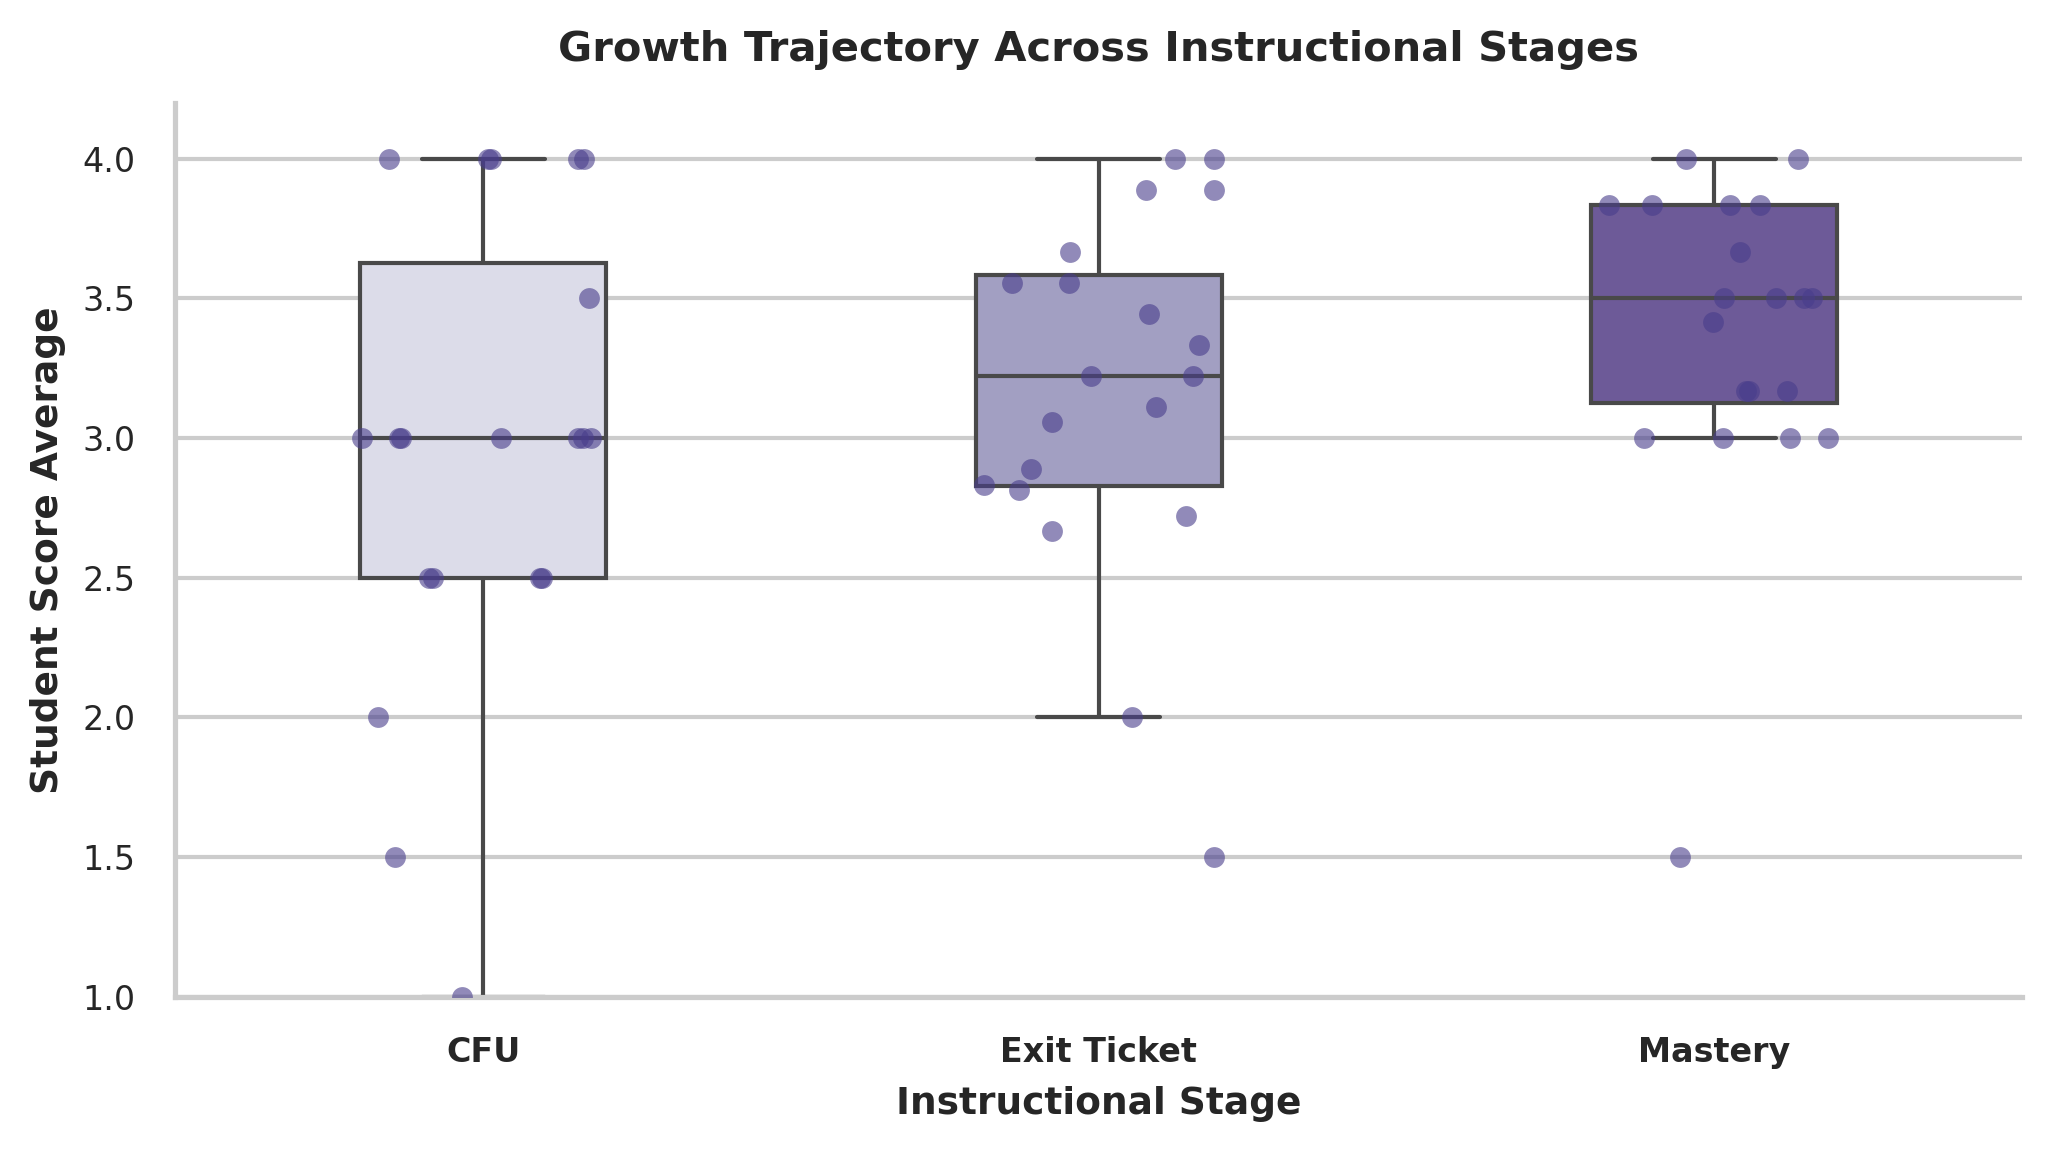

In [7]:
# Group columns by type
cfu_cols = [c for c in score_cols if 'CFU' in c]
exit_cols = [c for c in score_cols if 'Exit' in c or 'practice' in c]
mastery_cols = [c for c in score_cols if 'Mastery' in c]

# Create a stage dataframe
prog_df = pd.DataFrame({
    'CFU': clean_df2[cfu_cols].mean(axis=1),
    'Exit Ticket': clean_df2[exit_cols].mean(axis=1),
    'Mastery': clean_df2[mastery_cols].mean(axis=1)
}).melt(var_name='Assessment_Stage', value_name='Average_Score')

plt.figure(figsize=(7, 4), dpi=300)
sns.set_theme(style="whitegrid")

# Box and strip plot combo
sns.boxplot(
    data=prog_df, 
    x='Assessment_Stage', 
    y='Average_Score', 
    palette='Purples', 
    width=0.4, 
    fliersize=0
)
sns.stripplot(
    data=prog_df, 
    x='Assessment_Stage', 
    y='Average_Score', 
    color='darkslateblue', 
    alpha=0.6, 
    jitter=0.2, 
    size=5
)

plt.title("Growth Trajectory Across Instructional Stages", fontsize=10, fontweight='bold', pad=10)
plt.xlabel("Instructional Stage", fontsize=9, fontweight='bold')
plt.ylabel("Student Score Average", fontsize=9, fontweight='bold')
plt.ylim(1, 4.2)

plt.xticks(fontsize=8, fontweight='bold')
plt.yticks(fontsize=8)
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

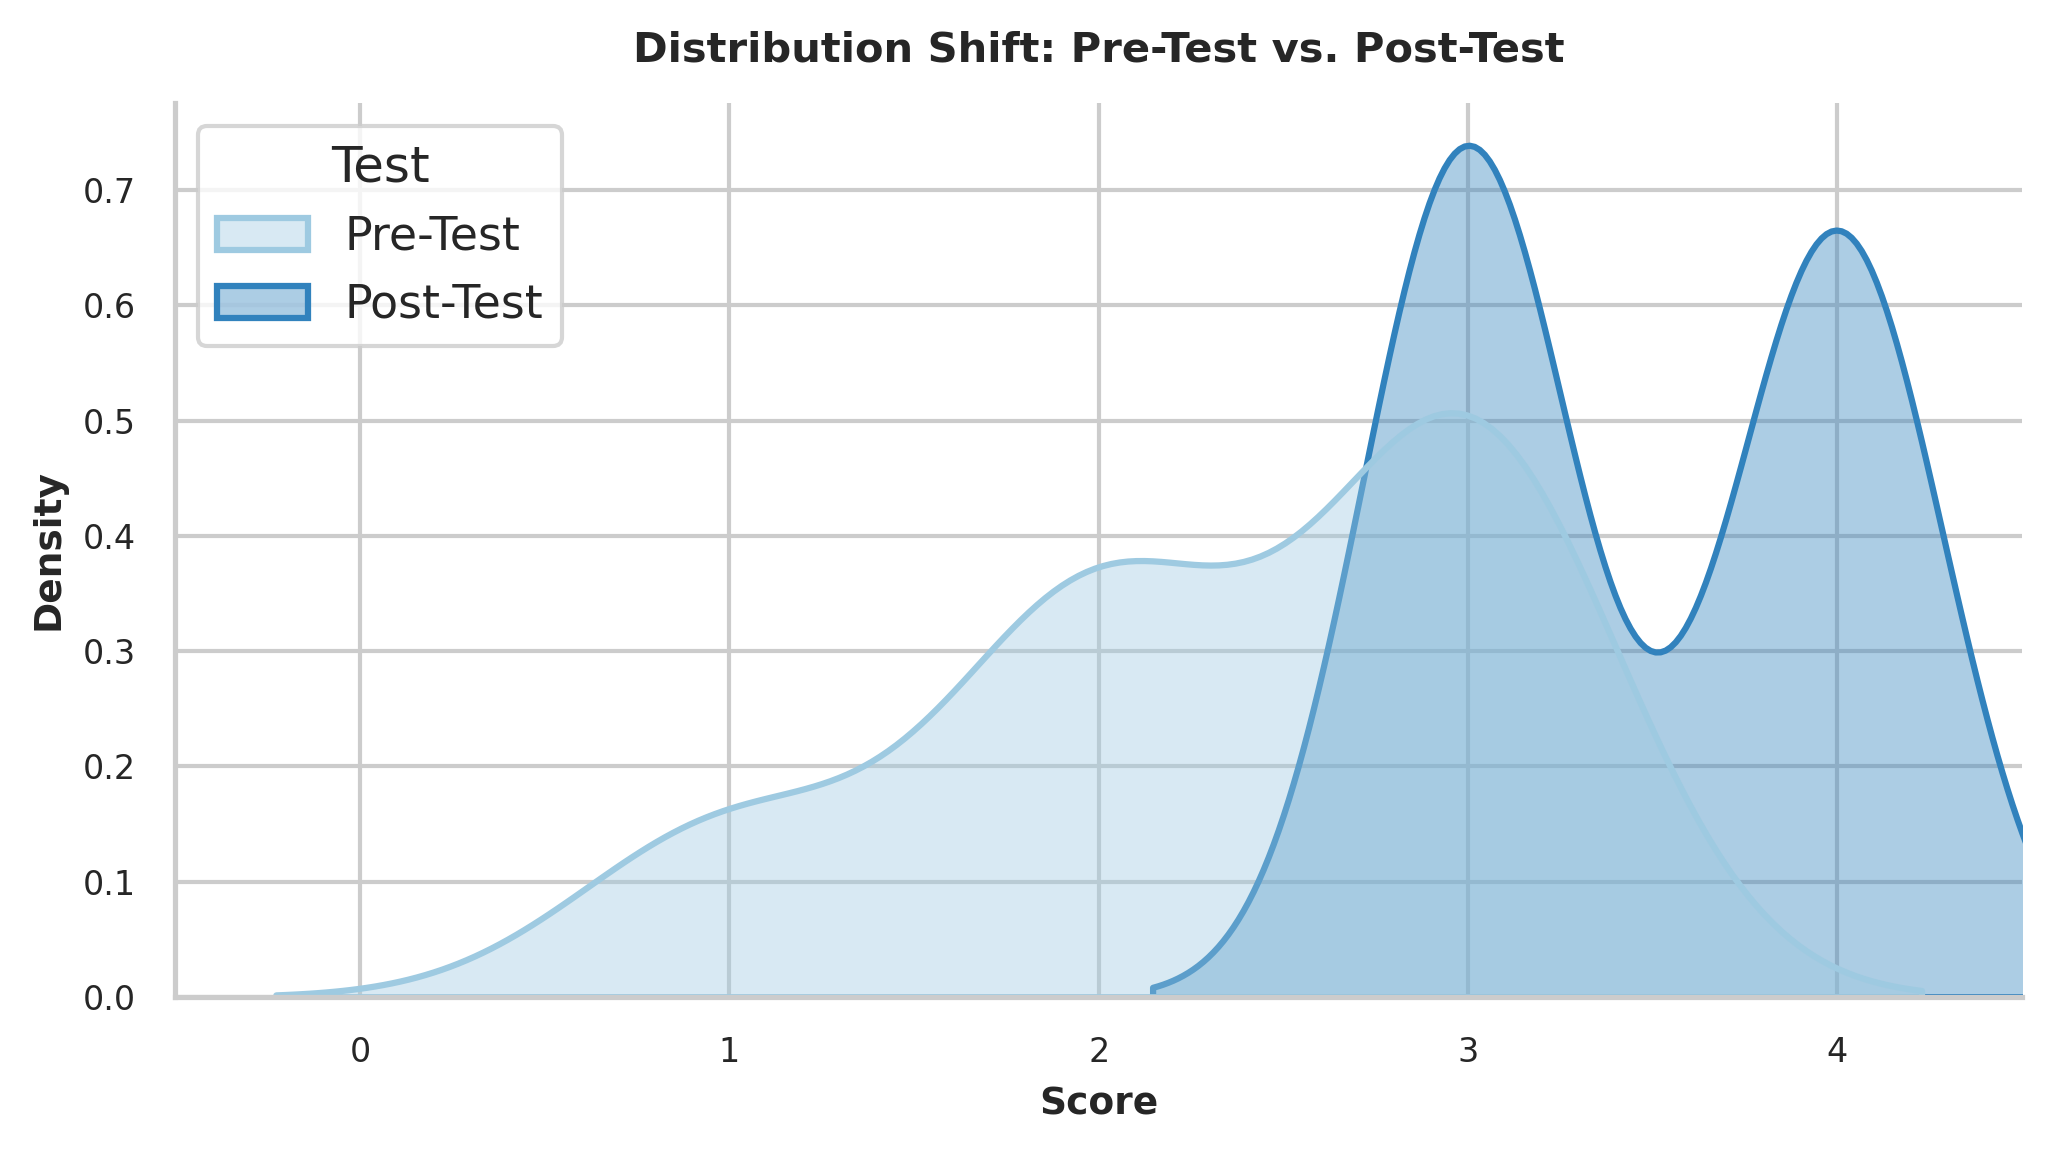

In [8]:
if 'Pre_Test' in clean_df2.columns and 'Post_Test_1' in clean_df2.columns:
    pre_post_df = clean_df2[['Pre_Test', 'Post_Test_1']].melt(var_name='Test', value_name='Score')
    pre_post_df['Test'] = pre_post_df['Test'].replace({'Pre_Test': 'Pre-Test', 'Post_Test_1': 'Post-Test'})

    plt.figure(figsize=(7, 4), dpi=300)
    sns.set_theme(style="whitegrid")

    sns.kdeplot(
        data=pre_post_df, 
        x='Score', 
        hue='Test', 
        fill=True, 
        common_norm=False, 
        palette=['#9ecae1', '#3182bd'], 
        alpha=0.4, 
        linewidth=1.5
    )

    plt.title("Distribution Shift: Pre-Test vs. Post-Test", fontsize=10, fontweight='bold', pad=10)
    plt.xlabel("Score", fontsize=9, fontweight='bold')
    plt.ylabel("Density", fontsize=9, fontweight='bold')
    plt.xlim(-0.5, 4.5)

    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    sns.despine(top=True, right=True)

    plt.tight_layout()
    plt.show()

In [10]:
from IPython.display import HTML, display

html_content = """
<div style="background: linear-gradient(135deg, #4C1D95 0%, #4C1D95 100%); padding: 22px 26px; border-radius: 10px; margin-bottom: 20px; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
    <h3 style="margin: 0 0 8px 0; color: #FFFFFF; font-size: 19px; font-weight: 700; border-bottom: none; padding: 0;">Data Set 2 Conclusions</h3>
    <div style="font-size: 14px; color: #E9D5FF; line-height: 1.6; font-weight: 400;">My analysis revealed a clear and measurable jump in scores when comparing pre-tests and post-tests, indicating overall student growth.</div>
</div>
"""

display(HTML(html_content))